# Lab 8: Representing Document Concepts with Embeddings 
## Team: Trojan Trio
## Member: Jinyao Yang, Qianshu Peng, Sen Pang

This notebook format was approved by TA Tanya via email for this assignment. A corresponding .py script containing only the code has also been provided
as requested.

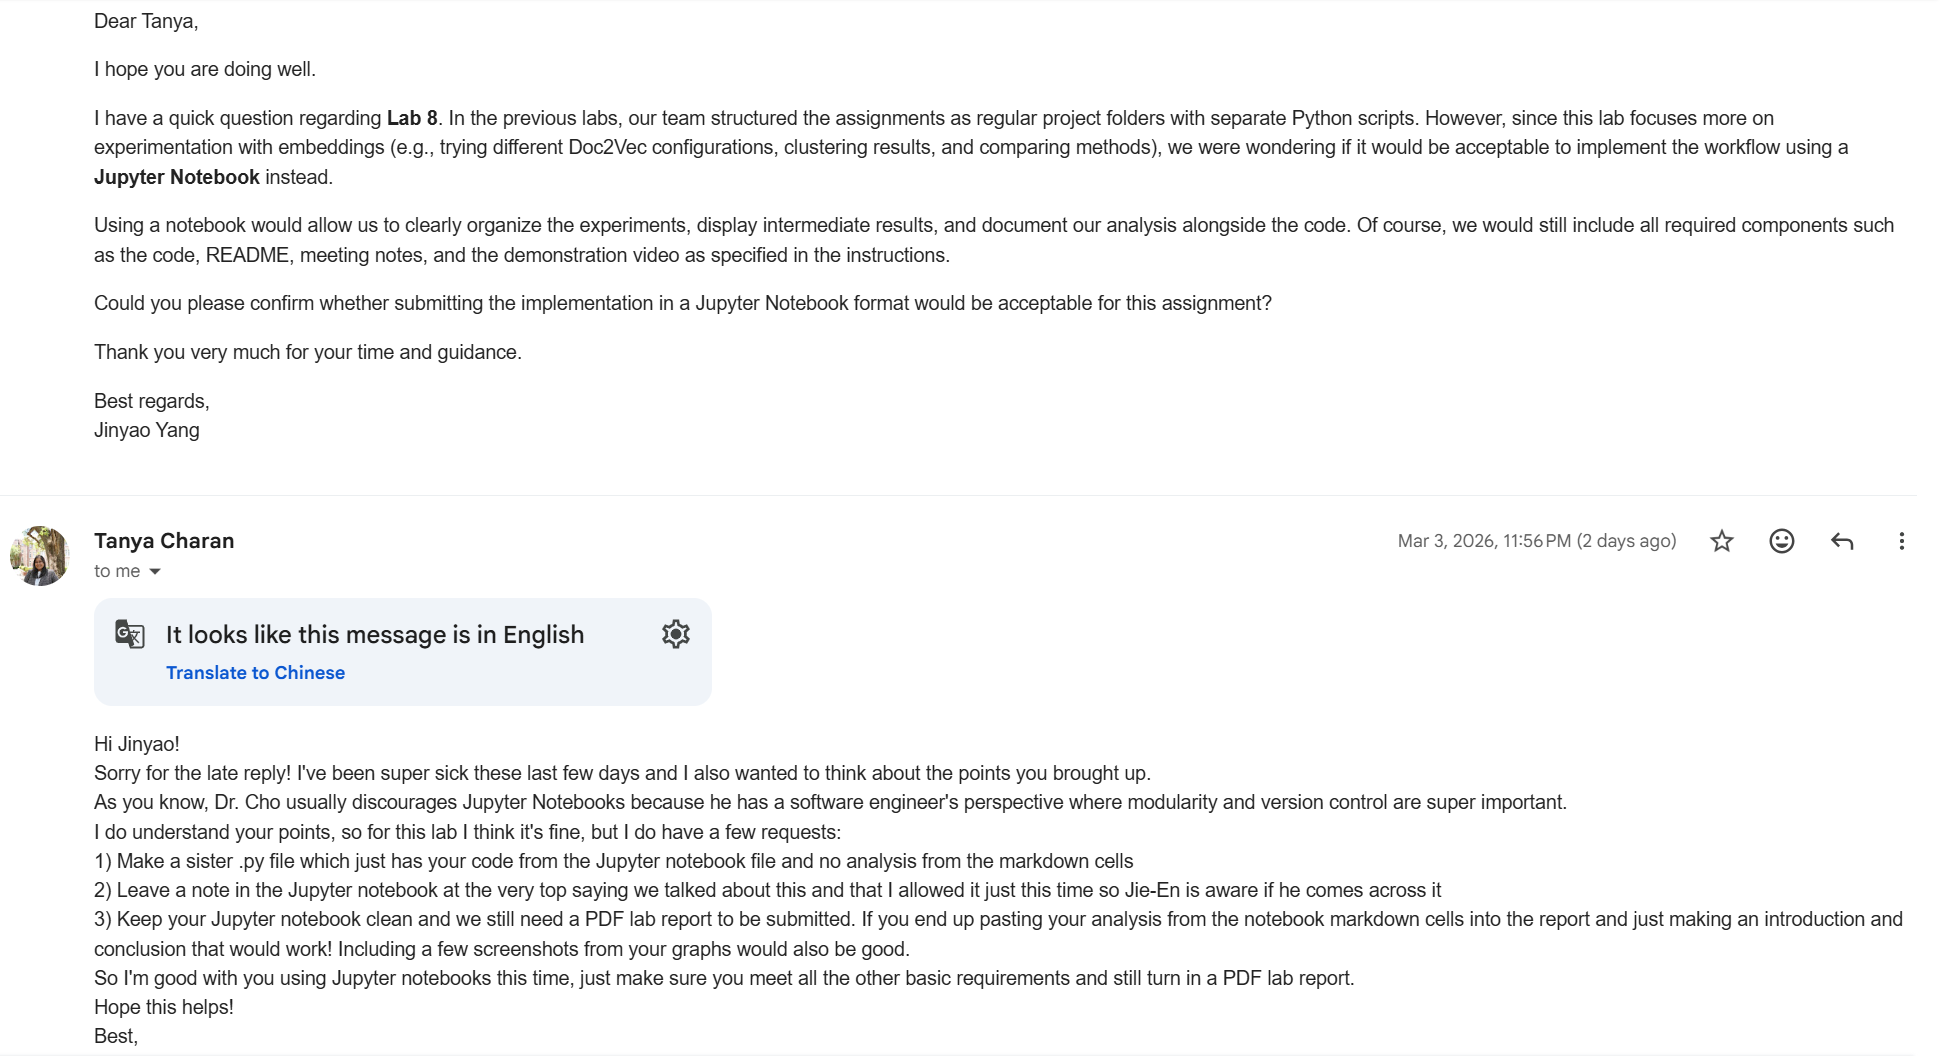

In [57]:
import json
import re
import html
import string
import random
from pathlib import Path
from itertools import product
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

from gensim.models import Doc2Vec, Word2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## Load Data

In [28]:
DATA_PATH = Path("data") / "posts_lab5_5000.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    posts = json.load(f)

assert isinstance(posts, list), "Expected a JSON list (array) of posts."
print("Total posts:", len(posts))


records = [
    p for p in posts
    if isinstance(p, dict)
    and isinstance(p.get("final_text"), str)
    and p.get("final_text").strip()
]

texts = [p["final_text"].strip() for p in records]

assert len(records) == len(texts), "records and texts are not aligned."

print("Non-empty texts:", len(texts))
print("Unique texts:", len(set(texts)), "/", len(texts))


sample = next((p for p in records if isinstance(p, dict)), None)
print("Sample keys:", list(sample.keys()) if sample else "EMPTY POSTS")


lengths = [len(t.split()) for t in texts]

if lengths:
    print("Min words:", min(lengths))
    print("Max words:", max(lengths))
    print("Average words:", sum(lengths) / len(lengths))
else:
    print("No non-empty texts found, cannot compute length stats.")

Total posts: 5000
Non-empty texts: 5000
Unique texts: 4936 / 5000
Sample keys: ['fullname', 'post_id', 'subreddit', 'title', 'author', 'author_raw', 'created_utc', 'created', 'permalink', 'out_url', 'domain', 'score', 'num_comments', 'is_self', 'body', 'final_text', 'is_image', 'is_gallery', 'image_url', 'gallery_urls', 'thumbnail', 'over_18', 'link_flair_text', 'ocr_text', 'keywords', 'topic']
Min words: 1
Max words: 3398
Average words: 71.8066


## Preprocessing

In [31]:
lengths = np.array([len(p.get("final_text","").split()) for p in posts])

print("p50:", np.percentile(lengths, 50))
print("p90:", np.percentile(lengths, 90))
print("p95:", np.percentile(lengths, 95))
print("p99:", np.percentile(lengths, 99))
print("max:", lengths.max())

p50: 21.0
p90: 187.0
p95: 266.0
p99: 623.1000000000022
max: 3398


In [59]:
TAG_RE = re.compile(r"<[^>]+>")
WS_RE  = re.compile(r"\s+")
URL_RE = re.compile(r"http\S+|www\.\S+")

def clean_text(text: str) -> str:
    if not text:
        return ""

    text = html.unescape(text)
    text = URL_RE.sub(" ", text)
    text = TAG_RE.sub(" ", text)
    text = text.replace("\u200b", " ").replace("\ufeff", " ")
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = WS_RE.sub(" ", text).strip()
    return text

In [35]:
MIN_WORDS = 4
MAX_WORDS = 583

clean_records = []
tokenized_docs = []

dropped_short = 0
truncated_long = 0
empty_after_clean = 0

for p in posts:
    if not isinstance(p, dict):
        continue

    raw_text = p.get("final_text")
    if not raw_text:
        raw_text = (p.get("title", "") + " " + p.get("body", ""))

    text = clean_text(raw_text)

    if not text:
        empty_after_clean += 1
        continue

    toks = text.split()

    if len(toks) < MIN_WORDS:
        dropped_short += 1
        continue

    if len(toks) > MAX_WORDS:
        toks = toks[:MAX_WORDS]
        truncated_long += 1

    clean_records.append(p)
    tokenized_docs.append(toks)

assert len(clean_records) == len(tokenized_docs)

print("Documents:", len(tokenized_docs))
print("Dropped (too short):", dropped_short)
print("Empty after clean:", empty_after_clean)
print("Truncated (too long):", truncated_long)

lengths = [len(t) for t in tokenized_docs]

print("Min words:", min(lengths) if lengths else 0)
print("Max words:", max(lengths) if lengths else 0)
print("Average words:", (sum(lengths)/len(lengths)) if lengths else 0)

Documents: 4986
Dropped (too short): 3
Empty after clean: 11
Truncated (too long): 56
Min words: 4
Max words: 583
Average words: 67.77797833935018


## Global Utility

In [61]:
def evaluate_clustering(X_norm, labels):
    n_clusters = len(set(labels))
    if n_clusters < 2:
        return {
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan
        }

    return {
        "silhouette": float(silhouette_score(X_norm, labels, metric="cosine")),
        "calinski_harabasz": float(calinski_harabasz_score(X_norm, labels)),
        "davies_bouldin": float(davies_bouldin_score(X_norm, labels)),
    }


def top_keywords_per_cluster(docs, labels, top_n=10, max_features=20000):
    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=3,
    )
    X = vectorizer.fit_transform(docs)
    terms = np.array(vectorizer.get_feature_names_out())

    out = {}
    labels = np.asarray(labels)

    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            out[int(c)] = []
            continue

        mean_scores = X[idx].mean(axis=0).A1
        top_idx = mean_scores.argsort()[::-1][:top_n]
        out[int(c)] = terms[top_idx].tolist()

    return out


def representative_docs(X_norm, labels, docs, per_cluster=3, records=None):
    labels = np.asarray(labels)
    reps = {}

    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            reps[int(c)] = []
            continue

        centroid = X_norm[idx].mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-12)

        sims = X_norm[idx] @ centroid
        top_local = np.argsort(-sims)[:per_cluster]
        chosen = idx[top_local]

        out = []
        for j, i in enumerate(chosen):
            item = {
                "doc_index": int(i),
                "cosine_to_centroid": float(sims[top_local[j]]),
                "preview": " ".join(docs[i].split()[:40])
            }

            if records is not None:
                item["title"] = records[i].get("title", "")
                item["subreddit"] = records[i].get("subreddit", "")
                item["permalink"] = records[i].get("permalink", "")

            out.append(item)

        reps[int(c)] = out

    return reps


def save_pca_plot(X, labels, outpath, title):
    X = normalize(X, norm="l2")
    labels = np.asarray(labels)

    pca = PCA(n_components=2, random_state=42)
    X2 = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        X2[:, 0],
        X2[:, 1],
        s=8,
        c=labels,
        cmap="tab10",
        alpha=0.7
    )
    plt.colorbar(sc, label="Cluster")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()
    plt.close()


def show_cluster_samples(labels, docs, tokenized_docs, n=3, max_len=140):
    labels = np.asarray(labels)
    buckets = {}
    BAD_TOKENS = {"s", "t", "m", "ve", "re", "d", "ll", "1", "2", "3", "4", "0"}

    for i, c in enumerate(labels):
        buckets.setdefault(int(c), []).append(i)

    for c in sorted(buckets.keys()):
        idxs = buckets[c]
        print(f"\n=== Cluster {c} (size={len(idxs)}) ===")

        words = []
        for idx in idxs:
            words.extend([
                w for w in tokenized_docs[idx]
                if w not in ENGLISH_STOP_WORDS and w not in BAD_TOKENS
            ])

        top_words = Counter(words).most_common(10)
        print("Top words:", top_words)

        for idx in idxs[:n]:
            print("-", docs[idx][:max_len])


def compute_cluster_balance(labels):
    cluster_sizes = Counter(labels)
    size_values = list(cluster_sizes.values())

    return {
        "cluster_sizes": dict(cluster_sizes),
        "largest_cluster_ratio": max(size_values) / len(labels),
        "smallest_cluster_size": min(size_values),
        "num_tiny_clusters": sum(1 for s in size_values if s < 20),
        "std_cluster_size": float(np.std(size_values)),
    }


clean_texts = [" ".join(doc) for doc in tokenized_docs]

## Task 1: Doc2Vec Document Embedding and Clustering

In [63]:
tagged_docs = [
    TaggedDocument(words=doc, tags=[i])
    for i, doc in enumerate(tokenized_docs)
]

print("Sample TaggedDocument:", tagged_docs[0])

Sample TaggedDocument: TaggedDocument<['big', 'blimp', 'uses', 'blades', 'to', 'pull', 'wind', 'power', 'out', 'of', 'the', 'sky'], [0]>


In [65]:
def train_doc2vec_get_X(
    tagged_docs,
    vector_size,
    min_count,
    epochs,
    window=5,
    workers=1,
    dm=1,
    negative=5,
    hs=0,
    sample=1e-4,
    seed=42,
):
    model = Doc2Vec(
        vector_size=vector_size,
        min_count=min_count,
        window=window,
        workers=workers,
        dm=dm,
        negative=negative,
        hs=hs,
        sample=sample,
        seed=seed
    )

    model.build_vocab(tagged_docs)

    model.train(
        tagged_docs,
        total_examples=model.corpus_count,
        epochs=epochs
    )

    vectors = np.vstack([
        model.dv[i] for i in range(len(tagged_docs))
    ]).astype(np.float32)

    X = normalize(vectors, norm="l2")
    return model, vectors, X

In [45]:
K_FIXED = 8

doc2vec_configs = [
    {"name": "D1", "vector_size": 50,  "min_count": 2, "epochs": 20},
    {"name": "D2", "vector_size": 100, "min_count": 3, "epochs": 30},
    {"name": "D3", "vector_size": 200, "min_count": 5, "epochs": 40},
]

doc2vec_vs_results = []

for cfg in doc2vec_configs:

    print(f"\nRunning Doc2Vec {cfg['name']} | "
          f"vector_size={cfg['vector_size']}, "
          f"min_count={cfg['min_count']}, "
          f"epochs={cfg['epochs']}")

    model, vectors, X = train_doc2vec_get_X(
        tagged_docs,
        vector_size=cfg["vector_size"],
        min_count=cfg["min_count"],
        epochs=cfg["epochs"],
        dm=1,
        seed=42,
        workers=1
    )

    km = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    metrics = evaluate_clustering(X, labels)
    balance = compute_cluster_balance(labels)

    doc2vec_vs_results.append({
        "config": cfg["name"],
        "vector_size": cfg["vector_size"],
        "min_count": cfg["min_count"],
        "epochs": cfg["epochs"],
        "silhouette_cosine": metrics["silhouette"],
        "calinski_harabasz": metrics["calinski_harabasz"],
        "davies_bouldin": metrics["davies_bouldin"],
        "largest_cluster_ratio": balance["largest_cluster_ratio"],
        "smallest_cluster_size": balance["smallest_cluster_size"],
        "num_tiny_clusters": balance["num_tiny_clusters"],
        "std_cluster_size": balance["std_cluster_size"],
    })

df_doc2vec_vs = pd.DataFrame(doc2vec_vs_results).sort_values(
    by=["silhouette_cosine", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n=== Doc2Vec configuration comparison ===")
display(df_doc2vec_vs)


Running Doc2Vec D1 | vector_size=50, min_count=2, epochs=20

Running Doc2Vec D2 | vector_size=100, min_count=3, epochs=30

Running Doc2Vec D3 | vector_size=200, min_count=5, epochs=40

=== Doc2Vec configuration comparison ===


,config,vector_size,min_count,epochs,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size
0,D1,50,2,20,0.216569,881.358647,1.713792,0.321099,44,0,520.738358
1,D2,100,3,30,0.192926,628.971870,1.921907,0.286001,246,0,420.652395
2,D3,200,5,40,0.149337,439.168252,2.202681,0.228239,354,0,240.008203


Three Doc2Vec configurations were first tested using different vector sizes and training parameters: 
D1 (vector_size=50, min_count=2, epochs=20), 
D2 (vector_size=100, min_count=3, epochs=30), and 
D3 (vector_size=200, min_count=5, epochs=40). 

The resulting document embeddings were clustered using cosine similarity and evaluated with 
Silhouette Score, Calinski–Harabasz Index, and Davies–Bouldin Index.

After this initial comparison, a broader parameter search was conducted over multiple values of 
min_count, epochs, and training architecture (dm). The final Doc2Vec configuration was selected 
based on both clustering metrics and cluster balance. The semantic-best configuration was:

vector_size = 200, min_count = 3, epochs = 20, dm = 1

This configuration produced more balanced clusters while maintaining reasonable clustering quality.

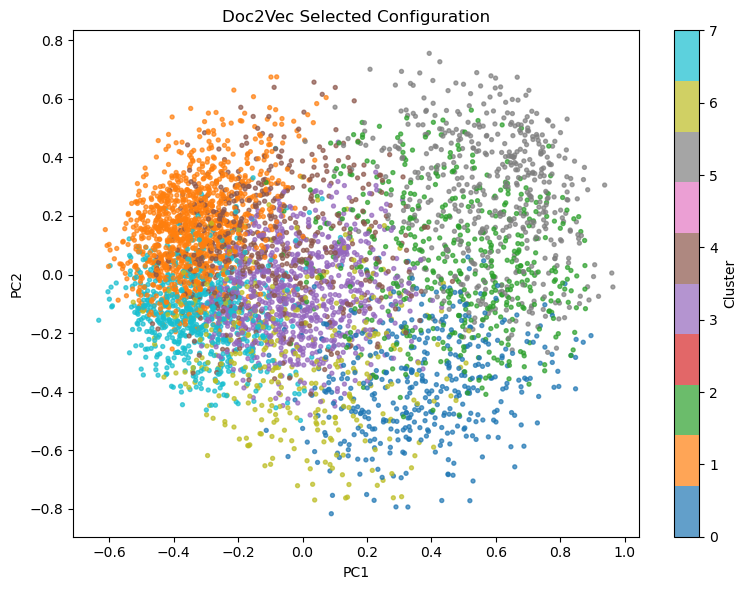


=== Cluster 0 (size=409) ===
Top words: [('like', 299), ('just', 221), ('data', 192), ('use', 160), ('time', 142), ('know', 136), ('understand', 130), ('does', 119), ('code', 113), ('computer', 108)]
- anything goes anyons may be at the root of surprising quantum experiments
- 15 minute hep c test makes same day treatment possible
- i know math isn t overly prominent in some areas of cybersecurity and that its more to do with understanding core concepts logic and algorit

=== Cluster 1 (size=1138) ===
Top words: [('ai', 329), ('data', 127), ('trump', 112), ('new', 84), ('says', 72), ('security', 68), ('000', 62), ('google', 61), ('billion', 53), ('2025', 50)]
- gene editing takes a major step toward ending daily cholesterol pills
- why apple and openai are reportedly betting on ai hardware in 2026
- battlefield wound spray stops bleeding in just one second

=== Cluster 2 (size=484) ===
Top words: [('data', 300), ('like', 195), ('ai', 181), ('learning', 126), ('just', 121), ('time', 11

In [50]:
best_cfg = {"name": "D3", "vector_size": 200, "min_count": 5, "epochs": 40}

model, vectors, X = train_doc2vec_get_X(
    tagged_docs,
    vector_size=best_cfg["vector_size"],
    min_count=best_cfg["min_count"],
    epochs=best_cfg["epochs"],
    dm=1,
    seed=42,
    workers=1
)

kmeans = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

top_words = top_keywords_per_cluster(clean_texts, labels, top_n=10)
reps = representative_docs(X, labels, clean_texts, per_cluster=3, records=clean_records)

save_pca_plot(vectors, labels, "doc2vec_best_pca.png", "Doc2Vec Selected Configuration")
show_cluster_samples(labels, clean_texts, tokenized_docs, n=3)

### Doc2Vec Clustering Results and Analysis

The clusters reveal several interpretable themes within the Reddit dataset. Cluster 0 contains a large portion of general technology and AI-related news posts, indicated by keywords such as ai, data, and model. Cluster 4 and Cluster 7 mainly include career-related discussions, particularly about jobs, data science, and machine learning roles. Some clusters, such as Cluster 2 and Cluster 5, appear to focus more on scientific or technological discoveries. Overall, the clusters capture meaningful topical structures in the dataset, suggesting that the Doc2Vec embeddings are able to represent the semantic relationships among documents reasonably well.

In [67]:
docs = [" ".join(toks) for toks in tokenized_docs]
records = clean_records

VECTOR_SIZE_FIXED = 200

min_count_grid = [2, 3, 5]
epochs_grid = [10, 20, 30, 40]
dm_grid = [0, 1]

task1_search_results = []

for mc, ep, dm in product(min_count_grid, epochs_grid, dm_grid):
    print(f"Running: vector_size={VECTOR_SIZE_FIXED}, min_count={mc}, epochs={ep}, dm={dm}")

    model, vectors, X = train_doc2vec_get_X(
        tagged_docs,
        vector_size=VECTOR_SIZE_FIXED,
        min_count=mc,
        epochs=ep,
        dm=dm,
        seed=42,
        workers=1
    )

    kmeans = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    metrics = evaluate_clustering(X, labels)
    balance = compute_cluster_balance(labels)
    top_words = top_keywords_per_cluster(docs, labels, top_n=10)
    reps = representative_docs(X, labels, docs, per_cluster=3, records=records)

    task1_search_results.append({
        "vector_size": VECTOR_SIZE_FIXED,
        "min_count": mc,
        "epochs": ep,
        "dm": dm,

        "model": model,
        "vectors": vectors,
        "X": X,
        "labels": labels,

        "silhouette_cosine": metrics["silhouette"],
        "calinski_harabasz": metrics["calinski_harabasz"],
        "davies_bouldin": metrics["davies_bouldin"],

        "cluster_sizes": balance["cluster_sizes"],
        "largest_cluster_ratio": balance["largest_cluster_ratio"],
        "smallest_cluster_size": balance["smallest_cluster_size"],
        "num_tiny_clusters": balance["num_tiny_clusters"],
        "std_cluster_size": balance["std_cluster_size"],

        "top_words": top_words,
        "representative_docs": reps,
    })

df_task1_search = pd.DataFrame([
    {
        "vector_size": r["vector_size"],
        "min_count": r["min_count"],
        "epochs": r["epochs"],
        "dm": r["dm"],
        "silhouette_cosine": r["silhouette_cosine"],
        "calinski_harabasz": r["calinski_harabasz"],
        "davies_bouldin": r["davies_bouldin"],
        "largest_cluster_ratio": r["largest_cluster_ratio"],
        "smallest_cluster_size": r["smallest_cluster_size"],
        "num_tiny_clusters": r["num_tiny_clusters"],
        "std_cluster_size": r["std_cluster_size"],
    }
    for r in task1_search_results
])

print("\n=== All Doc2Vec search results ===")
display(df_task1_search)

Running: vector_size=200, min_count=2, epochs=10, dm=0
Running: vector_size=200, min_count=2, epochs=10, dm=1
Running: vector_size=200, min_count=2, epochs=20, dm=0
Running: vector_size=200, min_count=2, epochs=20, dm=1
Running: vector_size=200, min_count=2, epochs=30, dm=0
Running: vector_size=200, min_count=2, epochs=30, dm=1
Running: vector_size=200, min_count=2, epochs=40, dm=0
Running: vector_size=200, min_count=2, epochs=40, dm=1
Running: vector_size=200, min_count=3, epochs=10, dm=0
Running: vector_size=200, min_count=3, epochs=10, dm=1
Running: vector_size=200, min_count=3, epochs=20, dm=0
Running: vector_size=200, min_count=3, epochs=20, dm=1
Running: vector_size=200, min_count=3, epochs=30, dm=0
Running: vector_size=200, min_count=3, epochs=30, dm=1
Running: vector_size=200, min_count=3, epochs=40, dm=0
Running: vector_size=200, min_count=3, epochs=40, dm=1
Running: vector_size=200, min_count=5, epochs=10, dm=0
Running: vector_size=200, min_count=5, epochs=10, dm=1
Running: v

,vector_size,min_count,epochs,dm,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size
0,200,2,10,0,0.007511,127.610838,2.800160,0.727036,1,2,1176.652429
1,200,2,10,1,0.366825,797.214815,3.211858,0.834136,9,1,1343.937847
2,200,2,20,0,0.164106,677.627329,1.916057,0.392098,33,0,716.148335
3,200,2,20,1,0.307154,1285.290059,1.410681,0.344364,46,0,554.019348
4,200,2,30,0,0.123630,395.918934,2.584386,0.323706,219,0,560.731832
5,200,2,30,1,0.195812,713.495687,1.925346,0.263337,296,0,342.041938
6,200,2,40,0,0.056351,259.348924,3.310398,0.231649,292,0,312.051979
7,200,2,40,1,0.150347,462.606499,2.169447,0.247493,367,0,264.684600
8,200,3,10,0,0.008257,123.568884,2.988489,0.714801,1,2,1157.031952
9,200,3,10,1,0.783730,771.455473,3.446810,0.909948,12,2,1480.289055


In [12]:
df_metric_ranked = df_task1_search.sort_values(
    by=["silhouette_cosine", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n=== Metric-best ranking ===")
display(df_metric_ranked.head(10))

best_metric_row = df_metric_ranked.iloc[0]

best_metric_result = next(
    r for r in task1_search_results
    if r["vector_size"] == best_metric_row["vector_size"]
    and r["min_count"] == best_metric_row["min_count"]
    and r["epochs"] == best_metric_row["epochs"]
    and r["dm"] == best_metric_row["dm"]
)

print("\n=== Best model by internal metrics ===")
print(best_metric_row)

print("\nCluster sizes (metric-best):")
print(best_metric_result["cluster_sizes"])


=== Metric-best ranking ===


,vector_size,min_count,epochs,dm,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size
0,200,3,10,1,0.807555,708.887107,3.253647,0.918072,7,1,1493.532808
1,200,3,20,0,0.557908,678.291172,1.741499,0.692169,32,0,1090.789851
2,200,5,20,0,0.536364,690.479247,1.848525,0.692369,36,0,1081.280260
3,200,2,20,0,0.532292,673.869950,1.851223,0.684940,32,0,1070.800752
4,200,2,20,1,0.328522,1303.037887,1.399821,0.380120,34,0,565.097116
5,200,3,20,1,0.309461,1268.660174,1.395099,0.359639,170,0,516.726717
6,200,2,10,1,0.300805,809.726073,3.265632,0.803815,12,1,1292.194548
7,200,2,10,0,0.293014,146.920245,1.674070,0.871084,1,4,1412.833147
8,200,5,10,1,0.292161,578.494639,3.492466,0.795984,8,1,1276.955853
9,200,5,20,1,0.258820,1184.561823,1.473625,0.327309,189,0,479.930724



=== Best model by internal metrics ===
vector_size               200.000000
min_count                   3.000000
epochs                     10.000000
dm                          1.000000
silhouette_cosine           0.807555
calinski_harabasz         708.887107
davies_bouldin              3.253647
largest_cluster_ratio       0.918072
smallest_cluster_size       7.000000
num_tiny_clusters           1.000000
std_cluster_size         1493.532808
Name: 0, dtype: float64

Cluster sizes (metric-best):
{0: 4572, 5: 176, 2: 69, 1: 31, 3: 37, 4: 44, 7: 44, 6: 7}


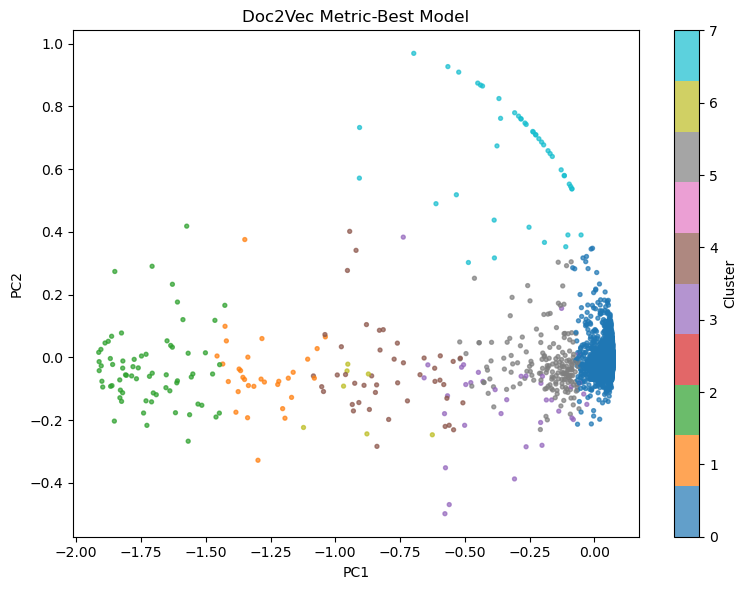


=== Metric-best cluster samples ===

=== Cluster 0 (size=4572) ===
Top words: [('ai', 1717), ('data', 1481), ('like', 1240), ('just', 1066), ('new', 652), ('work', 652), ('time', 649), ('use', 592), ('security', 536), ('know', 535)]
- china s new five year plan calls for ai throughout its economy tech breakthroughs
- wood polymer gives thermal paper an eco friendly makeover
- scientists discover plant compound that forces aggressive breast cancer cells into self destruction

=== Cluster 1 (size=31) ===
Top words: [('ai', 14), ('ceo', 5), ('says', 5), ('google', 5), ('job', 5), ('time', 4), ('tech', 4), ('researchers', 3), ('results', 3), ('got', 3)]
- researchers build a stretchable oled that can double in size without dimming
- nvidia ceo huang says 30 billion openai investment might be the last
- google is blocking ai searches for the president and dementia google appears to have blocked ai search results for questions about his menta

=== Cluster 2 (size=69) ===
Top words: [('ai', 

In [13]:
save_pca_plot(
    best_metric_result["X"],
    best_metric_result["labels"],
    "doc2vec_metric_best.png",
    "Doc2Vec Metric-Best Model"
)

print("\n=== Metric-best cluster samples ===")
show_cluster_samples(
    best_metric_result["labels"],
    docs,
    tokenized_docs,
    n=3
)

In [14]:
df_reasonable = df_task1_search[
    (df_task1_search["largest_cluster_ratio"] < 0.50) &
    (df_task1_search["num_tiny_clusters"] == 0) &
    (df_task1_search["smallest_cluster_size"] >= 30) &
    (df_task1_search["silhouette_cosine"] >= 0.20)
].copy()

df_semantic_ranked = df_reasonable.sort_values(
    by=[
        "silhouette_cosine",
        "calinski_harabasz",
        "davies_bouldin",
        "largest_cluster_ratio",
        "std_cluster_size"
    ],
    ascending=[False, False, True, True, True]
).reset_index(drop=True)

print("\n=== Semantic candidate ranking ===")
display(df_semantic_ranked.head(10))


=== Semantic candidate ranking ===


,vector_size,min_count,epochs,dm,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size
0,200,2,20,1,0.328522,1303.037887,1.399821,0.380120,34,0,565.097116
1,200,3,20,1,0.309461,1268.660174,1.395099,0.359639,170,0,516.726717
2,200,5,20,1,0.258820,1184.561823,1.473625,0.327309,189,0,479.930724
3,200,5,30,1,0.213114,661.664025,1.823753,0.290763,201,0,429.112165
4,200,2,30,1,0.208146,710.114761,1.898570,0.288956,226,0,367.310836
5,200,3,30,1,0.204526,694.573564,1.863411,0.247189,232,0,351.040240


In [15]:
semantic_choice = {"vector_size": 200, "min_count": 3, "epochs": 20, "dm": 1}

best_semantic_result = next(
    r for r in task1_search_results
    if r["vector_size"] == semantic_choice["vector_size"]
    and r["min_count"] == semantic_choice["min_count"]
    and r["epochs"] == semantic_choice["epochs"]
    and r["dm"] == semantic_choice["dm"]
)

print("\n=== Final semantic-best Doc2Vec model ===")
print(semantic_choice)
print("Cluster sizes:", best_semantic_result["cluster_sizes"])


=== Final semantic-best Doc2Vec model ===
{'vector_size': 200, 'min_count': 3, 'epochs': 20, 'dm': 1}
Cluster sizes: {1: 1791, 5: 1086, 0: 222, 7: 170, 2: 383, 6: 598, 3: 358, 4: 372}


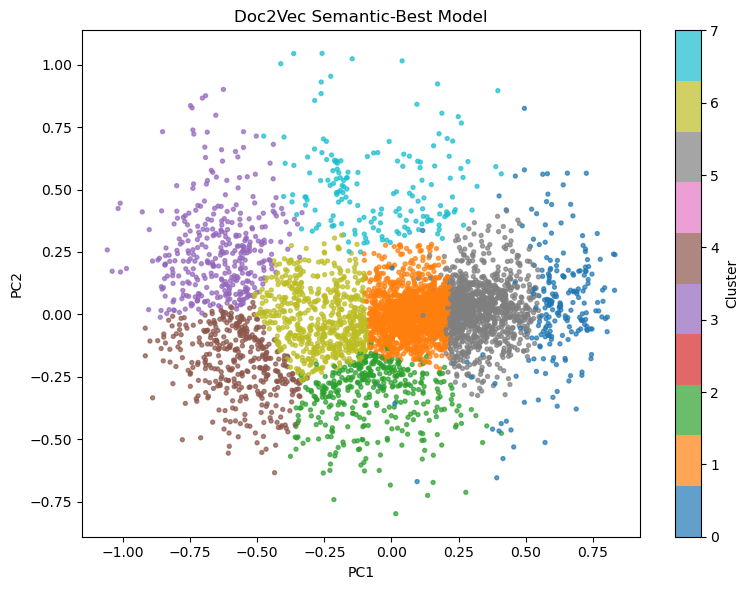


=== Semantic-best cluster samples ===

=== Cluster 0 (size=222) ===
Top words: [('ai', 197), ('agent', 94), ('data', 93), ('new', 67), ('access', 59), ('security', 56), ('agents', 54), ('google', 53), ('code', 50), ('5', 48)]
- human brain cells on a chip learned to play doom in a week
- brain inspired chip is helping robots to see faster and in real time
- sixteen claude ai agents working together created a new c compiler

=== Cluster 1 (size=1791) ===
Top words: [('ai', 423), ('new', 185), ('data', 172), ('like', 119), ('just', 104), ('use', 81), ('using', 80), ('security', 67), ('world', 64), ('models', 64)]
- china s new five year plan calls for ai throughout its economy tech breakthroughs
- wood polymer gives thermal paper an eco friendly makeover
- dissolvable hydrogel could enable personalized bone implants

=== Cluster 2 (size=383) ===
Top words: [('ai', 351), ('just', 211), ('like', 208), ('data', 120), ('use', 116), ('don', 112), ('code', 110), ('know', 105), ('time', 101), 

In [16]:
save_pca_plot(
    best_semantic_result["X"],
    best_semantic_result["labels"],
    "doc2vec_semantic_best.png",
    "Doc2Vec Semantic-Best Model"
)

print("\n=== Semantic-best cluster samples ===")
show_cluster_samples(
    best_semantic_result["labels"],
    docs,
    tokenized_docs,
    n=3
)

## Task 2: Word2Vec-Based Document Representation and Clustering

In [71]:
sentences = tokenized_docs   
print("Number of sentences:", len(sentences))

Number of sentences: 4986


In [73]:
vector_sizes = [50, 100, 200]

w2v_models = {}

for vs in vector_sizes:
    
    print(f"\nTraining Word2Vec vector_size={vs}")
    
    w2v = Word2Vec(
        sentences=sentences,
        vector_size=vs,
        window=5,
        min_count=3,
        workers=1,
        sg=0,
        epochs=20,
        seed=42
    )
    
    w2v_models[vs] = w2v
    
    print("Vocab size:", len(w2v.wv))


Training Word2Vec vector_size=50
Vocab size: 8339

Training Word2Vec vector_size=100
Vocab size: 8339

Training Word2Vec vector_size=200
Vocab size: 8339


In [75]:
task2_configs = [("A", 50), ("B", 100), ("C", 200)]

for name, vs in task2_configs:

    w2v = w2v_models[vs]

    words = list(w2v.wv.index_to_key)
    word_vecs = w2v.wv[words].astype(np.float32)

    print(f"\nModel {name} (vector_size={vs})")
    print("Vocabulary size:", len(words))
    print("Word vector shape:", word_vecs.shape)


Model A (vector_size=50)
Vocabulary size: 8339
Word vector shape: (8339, 50)

Model B (vector_size=100)
Vocabulary size: 8339
Word vector shape: (8339, 100)

Model C (vector_size=200)
Vocabulary size: 8339
Word vector shape: (8339, 200)


In [77]:
def cluster_words_into_bins(word_vecs, k):
    word_vecs_norm = normalize(word_vecs, norm="l2")

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    word_labels = km.fit_predict(word_vecs_norm)

    return word_labels


def build_word_to_bin(words, word_labels):
    assert len(words) == len(word_labels), "words and word_labels are not aligned."
    return {w: int(lbl) for w, lbl in zip(words, word_labels)}


def docs_to_bin_freq_vectors(tokenized_docs, word_to_bin, k):
    X = np.zeros((len(tokenized_docs), k), dtype=np.float32)
    zero_doc_count = 0

    for i, tokens in enumerate(tokenized_docs):
        count = 0

        for tok in tokens:
            if tok in word_to_bin:
                X[i, word_to_bin[tok]] += 1.0
                count += 1

        if count > 0:
            X[i] /= count
        else:
            zero_doc_count += 1

    return X, zero_doc_count

In [79]:
task2_results = []

for name, dim in task2_configs:
    print(f"Running Model {name}: vector_size={dim}, num_bins={dim}")

    w2v = w2v_models[dim]

    words = list(w2v.wv.index_to_key)
    word_vecs = w2v.wv[words].astype(np.float32)

    # 1) word -> bin
    word_labels = cluster_words_into_bins(word_vecs, dim)
    word_to_bin = build_word_to_bin(words, word_labels)

    # 2) docs -> bin frequency vectors
    X_doc, zero_doc_count = docs_to_bin_freq_vectors(tokenized_docs, word_to_bin, dim)
    print("Zero-vector docs:", zero_doc_count)

    # 3) normalize for cosine clustering
    X_doc = normalize(X_doc, norm="l2")

    # 4) drop all-zero vectors
    row_norms = np.linalg.norm(X_doc, axis=1)
    nonzero = row_norms > 0

    if not nonzero.all():
        print("[WARN] Dropping all-zero doc vectors:", int((~nonzero).sum()))

    X_use = X_doc[nonzero]
    docs_use = [d for d, keep in zip(clean_texts, nonzero) if keep]
    tokenized_use = [t for t, keep in zip(tokenized_docs, nonzero) if keep]
    records_use = [r for r, keep in zip(clean_records, nonzero) if keep]

    # 5) document clustering
    km = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
    doc_labels = km.fit_predict(X_use)

    # 6) internal metrics
    metrics = evaluate_clustering(X_use, doc_labels)

    # 7) cluster balance
    balance = compute_cluster_balance(doc_labels)

    # 8) semantic inspection
    top_words = top_keywords_per_cluster(docs_use, doc_labels, top_n=10)
    reps = representative_docs(
        X_use,
        doc_labels,
        docs_use,
        per_cluster=3,
        records=records_use
    )

    task2_results.append({
        "Model": name,
        "num_bins": dim,

        "X": X_use,
        "labels": doc_labels,
        "docs_use": docs_use,
        "tokenized_use": tokenized_use,
        "records_use": records_use,

        "silhouette_cosine": metrics["silhouette"],
        "calinski_harabasz": metrics["calinski_harabasz"],
        "davies_bouldin": metrics["davies_bouldin"],

        "cluster_sizes": balance["cluster_sizes"],
        "largest_cluster_ratio": balance["largest_cluster_ratio"],
        "smallest_cluster_size": balance["smallest_cluster_size"],
        "num_tiny_clusters": balance["num_tiny_clusters"],
        "std_cluster_size": balance["std_cluster_size"],

        "top_words": top_words,
        "representative_docs": reps,
    })



# Metric ranking (Task2 main result)
df_task2_metric_ranked = pd.DataFrame([
    {
        "Model": r["Model"],
        "num_bins": r["num_bins"],
        "silhouette_cosine": r["silhouette_cosine"],
        "calinski_harabasz": r["calinski_harabasz"],
        "davies_bouldin": r["davies_bouldin"],
        "largest_cluster_ratio": r["largest_cluster_ratio"],
        "smallest_cluster_size": r["smallest_cluster_size"],
        "num_tiny_clusters": r["num_tiny_clusters"],
        "std_cluster_size": r["std_cluster_size"],
    }
    for r in task2_results
]).sort_values(
    by=["silhouette_cosine", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n=== Word2Vec configuration comparison ===")
display(df_task2_metric_ranked)

best_metric_w2v_row = df_task2_metric_ranked.iloc[0]
best_metric_w2v_result = next(
    r for r in task2_results
    if r["Model"] == best_metric_w2v_row["Model"]
)

print("\n=== Best Word2Vec model ===")
print(best_metric_w2v_row)

print("\nCluster sizes (best Word2Vec):")
print(best_metric_w2v_result["cluster_sizes"])

Running Model A: vector_size=50, num_bins=50
Zero-vector docs: 0
Running Model B: vector_size=100, num_bins=100
Zero-vector docs: 0
Running Model C: vector_size=200, num_bins=200
Zero-vector docs: 0

=== Word2Vec configuration comparison ===


,Model,num_bins,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size
0,A,50,0.248882,364.971102,2.670477,0.395106,229,0,521.694295
1,B,100,0.073864,259.040460,3.384807,0.253510,313,0,303.720163
2,C,200,0.049086,160.031189,4.109824,0.192339,347,0,232.725026



=== Best Word2Vec model ===
Model                             A
num_bins                         50
silhouette_cosine          0.248882
calinski_harabasz        364.971102
davies_bouldin             2.670477
largest_cluster_ratio      0.395106
smallest_cluster_size           229
num_tiny_clusters                 0
std_cluster_size         521.694295
Name: 0, dtype: object

Cluster sizes (best Word2Vec):
{1: 543, 0: 1970, 4: 458, 3: 576, 7: 468, 5: 269, 2: 473, 6: 229}


For Task 2, three Word2Vec-based configurations were tested using different numbers of bins 
(50, 100, and 200). Word embeddings were first clustered into bins, and each document was then 
represented as a normalized frequency vector over those bins.

The resulting document representations were clustered using K-Means and evaluated with 
Silhouette Score, Calinski–Harabasz Index, and Davies–Bouldin Index.

Among the three configurations, Model A (50 bins) achieved the best overall clustering quality 
according to the internal evaluation metrics. Therefore, Model A was selected as the best 
Word2Vec-based document representation for further qualitative inspection and visualization.

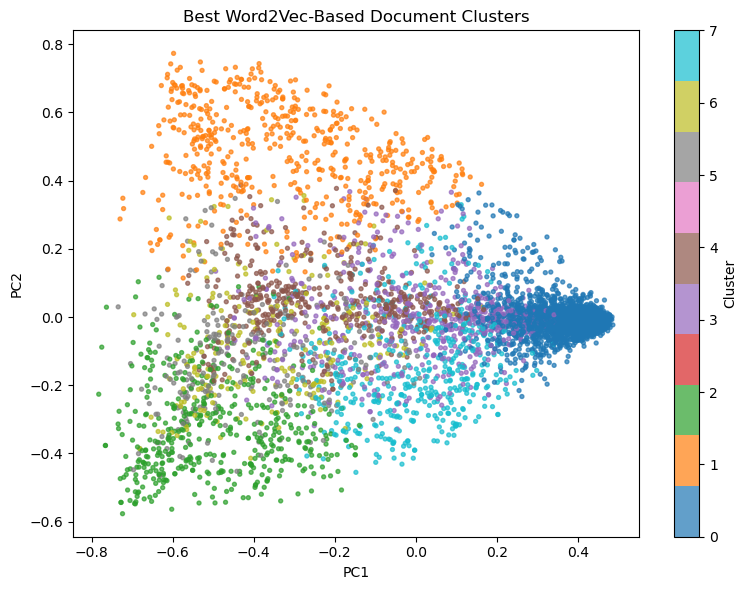


=== Cluster 0 (size=1970) ===
Top words: [('data', 1224), ('like', 1180), ('just', 988), ('ai', 905), ('work', 622), ('time', 565), ('use', 496), ('know', 495), ('people', 473), ('want', 431)]
- engineers just developed a perfect material for a truly unsinkable ship
- people could be resurrected in robotic bodies one day futurist believes now he s taken the first step
- the large hadron collider will now heat homes as well as smash particles

=== Cluster 1 (size=543) ===
Top words: [('new', 172), ('cancer', 66), ('cells', 55), ('researchers', 51), ('brain', 49), ('drug', 45), ('scientists', 43), ('ai', 42), ('breakthrough', 38), ('treatment', 34)]
- big blimp uses blades to pull wind power out of the sky
- sugar molecules used to destroy antibiotic resistant bacteria
- a quick stretch switches this polymer s capacity to transport heat

=== Cluster 2 (size=473) ===
Top words: [('ai', 128), ('trump', 75), ('says', 75), ('ceo', 46), ('google', 39), ('openai', 35), ('new', 31), ('musk', 2

In [81]:
save_pca_plot(
    best_metric_w2v_result["X"],
    best_metric_w2v_result["labels"],
    "task2_best_w2v_pca.png",
    "Best Word2Vec-Based Document Clusters"
)


show_cluster_samples(
    best_metric_w2v_result["labels"],
    best_metric_w2v_result["docs_use"],
    best_metric_w2v_result["tokenized_use"],
    n=3
)

print("\n=== Top keywords per cluster (best Word2Vec) ===")
for c, kws in best_metric_w2v_result["top_words"].items():
    print(f"Cluster {c}: {kws}")

### Word2Vec Clustering Results and Analysis

The Word2Vec-based document representation also produced several interpretable clusters. 
Some clusters mainly contain discussions related to artificial intelligence, data science, 
and technology news, while others focus more on scientific discoveries and engineering topics.

Although several clusters show coherent topical patterns, some clusters remain relatively broad 
and include posts from multiple related technology areas. This suggests that the Word2Vec 
bin-frequency representation captures general thematic similarities but may produce less 
precise semantic groupings compared with Doc2Vec embeddings.

In [84]:
task2_results = []

for name, num_bins in task2_configs:
    print(f"Running Model {name}: vector_size={num_bins}, num_bins={num_bins}")

    # use the matching Word2Vec model
    w2v = w2v_models[num_bins]

    words = list(w2v.wv.index_to_key)
    word_vecs = np.vstack([w2v.wv[w] for w in words]).astype(np.float32)

    # 1) word -> bin
    word_labels = cluster_words_into_bins(word_vecs, num_bins)
    word_to_bin = build_word_to_bin(words, word_labels)

    # 2) docs -> bin frequency vectors
    X_doc, zero_doc_count = docs_to_bin_freq_vectors(tokenized_docs, word_to_bin, num_bins)
    print("Zero-vector docs:", zero_doc_count)

    # 3) normalize for cosine clustering
    X_doc = normalize(X_doc, norm="l2")

    # 4) drop all-zero vectors
    row_norms = np.linalg.norm(X_doc, axis=1)
    nonzero = row_norms > 0

    if not nonzero.all():
        print("[WARN] Dropping all-zero doc vectors:", int((~nonzero).sum()))

    X_use = X_doc[nonzero]
    docs_use = [d for d, keep in zip(docs, nonzero) if keep]
    tokenized_use = [t for t, keep in zip(tokenized_docs, nonzero) if keep]
    records_use = [r for r, keep in zip(records, nonzero) if keep]

    # 5) document clustering
    km = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
    doc_labels = km.fit_predict(X_use)

    # 6) internal metrics
    metrics = evaluate_clustering(X_use, doc_labels)

    # 7) cluster balance
    balance = compute_cluster_balance(doc_labels)

    # 8) semantic interpretability signals
    top_words = top_keywords_per_cluster(docs_use, doc_labels, top_n=10)
    reps = representative_docs(
        X_use,
        doc_labels,
        docs_use,
        per_cluster=3,
        records=records_use
    )

    task2_results.append({
        "Model": name,
        "vector_size": num_bins,
        "num_bins": num_bins,

        "X": X_use,
        "labels": doc_labels,
        "docs_use": docs_use,
        "tokenized_use": tokenized_use,
        "records_use": records_use,

        "silhouette_cosine": metrics["silhouette"],
        "calinski_harabasz": metrics["calinski_harabasz"],
        "davies_bouldin": metrics["davies_bouldin"],

        "cluster_sizes": balance["cluster_sizes"],
        "largest_cluster_ratio": balance["largest_cluster_ratio"],
        "smallest_cluster_size": balance["smallest_cluster_size"],
        "num_tiny_clusters": balance["num_tiny_clusters"],
        "std_cluster_size": balance["std_cluster_size"],

        "top_words": top_words,
        "representative_docs": reps,
    })


# 1) Metric-best ranking

df_task2_metric_ranked = pd.DataFrame([
    {
        "Model": r["Model"],
        "num_bins": r["num_bins"],
        "silhouette_cosine": r["silhouette_cosine"],
        "calinski_harabasz": r["calinski_harabasz"],
        "davies_bouldin": r["davies_bouldin"],
        "largest_cluster_ratio": r["largest_cluster_ratio"],
        "smallest_cluster_size": r["smallest_cluster_size"],
        "num_tiny_clusters": r["num_tiny_clusters"],
        "std_cluster_size": r["std_cluster_size"],
    }
    for r in task2_results
]).sort_values(
    by=["silhouette_cosine", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n=== Word2Vec metric-best ranking ===")
display(df_task2_metric_ranked)

best_metric_w2v_row = df_task2_metric_ranked.iloc[0]
best_metric_w2v_result = next(
    r for r in task2_results
    if r["Model"] == best_metric_w2v_row["Model"]
)

print("\n=== Best Word2Vec model by internal metrics ===")
print(best_metric_w2v_row)

print("\nCluster sizes (metric-best Word2Vec):")
print(best_metric_w2v_result["cluster_sizes"])



# 2) Semantic candidate ranking

df_task2_reasonable = df_task2_metric_ranked[
    (df_task2_metric_ranked["largest_cluster_ratio"] < 0.60) &
    (df_task2_metric_ranked["num_tiny_clusters"] <= 2) &
    (df_task2_metric_ranked["smallest_cluster_size"] >= 10) &
    (df_task2_metric_ranked["silhouette_cosine"] >= 0.10)
].copy()

df_task2_semantic_ranked = df_task2_reasonable.sort_values(
    by=[
        "silhouette_cosine",
        "calinski_harabasz",
        "davies_bouldin",
        "largest_cluster_ratio",
        "num_tiny_clusters",
        "std_cluster_size"
    ],
    ascending=[False, False, True, True, True, True]
).reset_index(drop=True)

print("\n=== Word2Vec semantic candidate ranking ===")
display(df_task2_semantic_ranked)

semantic_top3_w2v = df_task2_semantic_ranked.head(3)
print("\n=== Top 3 semantic candidates (Word2Vec) ===")
display(semantic_top3_w2v)

Running Model A: vector_size=50, num_bins=50
Zero-vector docs: 0
Running Model B: vector_size=100, num_bins=100
Zero-vector docs: 0
Running Model C: vector_size=200, num_bins=200
Zero-vector docs: 0

=== Word2Vec metric-best ranking ===


,Model,num_bins,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size
0,A,50,0.248882,364.971102,2.670477,0.395106,229,0,521.694295
1,B,100,0.073864,259.040460,3.384807,0.253510,313,0,303.720163
2,C,200,0.049086,160.031189,4.109824,0.192339,347,0,232.725026



=== Best Word2Vec model by internal metrics ===
Model                             A
num_bins                         50
silhouette_cosine          0.248882
calinski_harabasz        364.971102
davies_bouldin             2.670477
largest_cluster_ratio      0.395106
smallest_cluster_size           229
num_tiny_clusters                 0
std_cluster_size         521.694295
Name: 0, dtype: object

Cluster sizes (metric-best Word2Vec):
{1: 543, 0: 1970, 4: 458, 3: 576, 7: 468, 5: 269, 2: 473, 6: 229}

=== Word2Vec semantic candidate ranking ===


,Model,num_bins,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size
0,A,50,0.248882,364.971102,2.670477,0.395106,229,0,521.694295



=== Top 3 semantic candidates (Word2Vec) ===


,Model,num_bins,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size
0,A,50,0.248882,364.971102,2.670477,0.395106,229,0,521.694295


In [24]:
semantic_choice_w2v = "A"

best_semantic_w2v_result = next(
    r for r in task2_results
    if r["Model"] == semantic_choice_w2v
)

print("\n=== Final semantic-best Word2Vec model ===")
print("Model:", semantic_choice_w2v)
print("num_bins:", best_semantic_w2v_result["num_bins"])

print("\nNote:")
print("The semantic-best Word2Vec model is the same as the metric-best model.")


=== Final semantic-best Word2Vec model ===
Model: A
num_bins: 50

Note:
The semantic-best Word2Vec model is the same as the metric-best model.


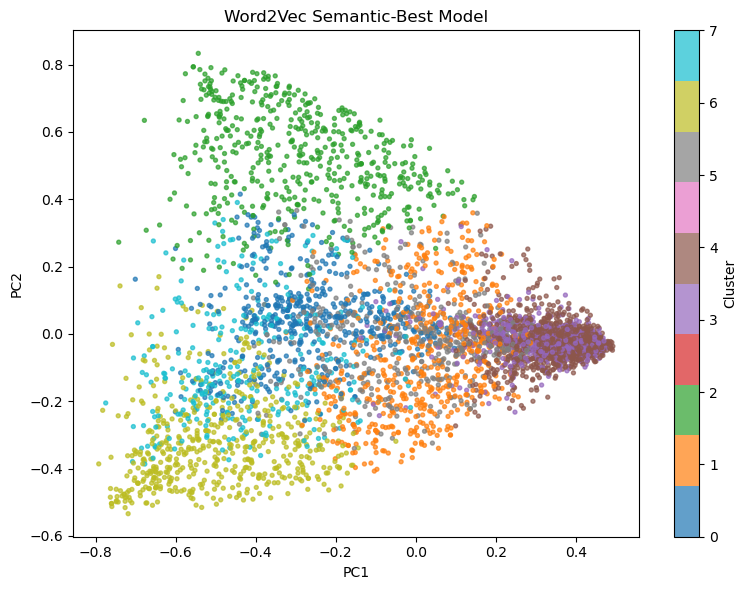


=== Cluster 0 (size=483) ===
Top words: [('ai', 157), ('data', 78), ('agent', 62), ('new', 51), ('code', 50), ('5', 46), ('agents', 45), ('security', 43), ('open', 41), ('github', 39)]
- china s new five year plan calls for ai throughout its economy tech breakthroughs
- this device uses a laser to shoot down 30 mosquitoes per second lidar guided photonmatrix has up to 6 meter kill zone can gauge distance ori
- schr dinger s color theory finally completed after 100 years

=== Cluster 1 (size=584) ===
Top words: [('ai', 126), ('data', 57), ('trump', 49), ('new', 48), ('just', 43), ('security', 39), ('says', 38), ('group', 35), ('like', 31), ('5', 30)]
- wood polymer gives thermal paper an eco friendly makeover
- china invents process that turns desert sand into fertile soil in just 10 months
- asml unveils euv light source advance that could yield 50 more chips by 2030

=== Cluster 2 (size=526) ===
Top words: [('new', 184), ('cancer', 64), ('cells', 59), ('brain', 50), ('drug', 48), ('s

In [25]:
semantic_choice_w2v = "A"

best_semantic_w2v_result = next(
    r for r in task2_results
    if r["Model"] == semantic_choice_w2v
)

save_pca_plot(
    best_semantic_w2v_result["X"],
    best_semantic_w2v_result["labels"],
    "w2v_semantic_best.png",
    "Word2Vec Semantic-Best Model"
)

show_cluster_samples(
    best_semantic_w2v_result["labels"],
    best_semantic_w2v_result["docs_use"],
    best_semantic_w2v_result["tokenized_use"],
    n=3
)

## Comparative Analysis

In this experiment, we compared two different approaches for representing and clustering 
technology-related Reddit posts: Doc2Vec document embeddings and Word2Vec-based 
bin-frequency document representations.

Doc2Vec learns document-level embeddings directly during training, which allows the model 
to capture semantic relationships between entire documents. As a result, the Doc2Vec-based 
representation tends to produce clusters that reflect more coherent semantic themes across 
posts. In our experiments, the semantic-best Doc2Vec configuration (vector_size = 200, 
min_count = 3, epochs = 20, dm = 1) generated relatively balanced clusters and showed 
clear topical patterns when inspecting representative documents and keywords.

In contrast, the Word2Vec-based approach first learns word embeddings and then groups words 
into bins using clustering. Each document is represented by the normalized frequency of 
words belonging to these bins. This approach captures general topical signals but does not 
directly model document-level semantics. As a result, the clusters produced by the Word2Vec 
bin-frequency representation are somewhat broader and may mix related technology topics 
within the same cluster.

From the internal clustering metrics, the best Word2Vec configuration used 50 bins and 
achieved reasonable clustering quality. However, compared with Doc2Vec, the Word2Vec-based 
representation showed slightly weaker semantic separation between clusters during 
qualitative inspection.

Overall, the comparison suggests that Doc2Vec embeddings are more effective at capturing 
document-level semantic structure in short technology-related texts, while the Word2Vec 
bin-frequency approach provides a simpler representation that still reveals general topic 
patterns in the dataset.

## Conclusion

In this assignment, we compared two approaches for representing and clustering 
technology-related Reddit posts: Doc2Vec document embeddings and Word2Vec-based 
bin-frequency document representations.

For Doc2Vec, multiple configurations were tested with different vector sizes and 
training parameters. After performing both metric-based evaluation and semantic 
inspection, the configuration with vector_size = 200, min_count = 3, epochs = 20, 
and dm = 1 was selected as the final Doc2Vec model. This configuration produced 
reasonably balanced clusters while maintaining good clustering quality.

For the Word2Vec-based representation, word embeddings were first clustered into 
bins and documents were represented using normalized bin-frequency vectors. 
Among the tested configurations (50, 100, and 200 bins), the 50-bin configuration 
achieved the best performance according to internal clustering metrics.

Overall, both approaches were able to discover meaningful thematic groupings in 
the dataset, including discussions related to artificial intelligence, 
cybersecurity, and scientific research. However, the Doc2Vec representation 
generally produced more semantically coherent clusters, suggesting that 
document-level embeddings are more effective for capturing the semantic 
structure of short technology-related texts.

In [ ]:
!jupyter nbconvert --to script "lab 8.ipynb"